# Conv1D Hybrid Autoencoder — Entrenamiento Final
## Dataset: SWaT A12 (Marzo 2026)

Notebook de entrenamiento completo del detector Conv1D, usando los hiperparámetros
óptimos encontrados por Optuna en `01a`.

### Hiperparámetros seleccionados (mejor trial Optuna)

| Parámetro | Valor | Nota |
|-----------|-------|------|
| `window_size` | 30 | Ventana más corta que A7 (60) — dataset de 8h |
| `stride` | 5 | 3,069 ventanas de train |
| `n_conv_layers` | 1 | Arquitectura mínima — evita overfitting con pocos datos |
| `conv_channels_1` | 32 | Único bloque Conv1D |
| `kernel_size` | 5 | |
| `disc_hidden_1/2` | 64/32 | |
| `fusion_hidden` | 128 | |
| `dropout` | 0.186 | |
| `batch_size` | 64 | |
| `lr` | 8.62e-4 | AdamW |
| `alpha` (cont/disc) | 0.306 | Loss pesada hacia discretas (69%) |

### Corrección respecto a la verificación en 01a

La verificación final de 01a entrenó 50 epochs y mostró overfitting
(val_loss subió de 0.412 en epoch 40 a 0.487 en epoch 50). Este notebook
usa **checkpointing del mejor val_loss** para guardar el modelo del epoch óptimo,
más **ReduceLROnPlateau** para comprimir más la val_loss antes de que el pruner
de Optuna interviniera.

### Salidas de este notebook

Todo lo que los notebooks posteriores (TimeGAN, TSTR) necesitan:
```
models/detectors/conv1d_hybrid_a12/
├── model_state.pt               ← modelo en el mejor epoch
├── scaler_cont.pkl              ← ya existía de 01a
├── disc_max_dict.pkl            ← ya existía de 01a
├── tau_dict.json                ← umbrales de detección (p90–p99.5)
├── columns_config.json          ← continuous_cols, discrete_cols, feature_cols
└── config.json                  ← todos los hiperparámetros + métricas
```


## 0. Imports

In [11]:
import json
import joblib
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score


In [12]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas

In [13]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

RAW_CSV  = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"
SAVE_DIR = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_a12"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

OPTUNA_CONFIG = SAVE_DIR / "optuna_best_config.json"

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("CSV exists  :", RAW_CSV.exists())
print("Optuna cfg  :", OPTUNA_CONFIG.exists())


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
CSV exists  : True
Optuna cfg  : True


## 2. Cargar configuración óptima de Optuna

In [14]:
with open(OPTUNA_CONFIG) as f:
    optuna_cfg = json.load(f)

bp = optuna_cfg["best_params"]    # mejores hiperparámetros
continuous_cols = optuna_cfg["continuous_cols"]
discrete_cols   = optuna_cfg["discrete_cols"]
feature_cols    = optuna_cfg["feature_cols"]

WINDOW_SIZE = bp["window_size"]
STRIDE      = bp["stride"]

print("Hiperparámetros cargados:")
for k, v in bp.items():
    print(f"  {k:20s}: {v}")
print(f"\ncontinuous_cols: {len(continuous_cols)}")
print(f"discrete_cols:   {len(discrete_cols)}")
print(f"feature_cols:    {len(feature_cols)}")
print(f"window_size:     {WINDOW_SIZE} | stride: {STRIDE}")


Hiperparámetros cargados:
  window_size         : 30
  stride              : 5
  n_conv_layers       : 1
  conv_channels_1     : 32
  conv_channels_2     : 8
  conv_channels_3     : 4
  kernel_size         : 5
  disc_hidden_1       : 64
  disc_hidden_2       : 32
  fusion_hidden       : 128
  dropout             : 0.18603688941537255
  batch_size          : 64
  lr                  : 0.0008622931547331273
  optimizer           : AdamW
  epochs              : 40
  alpha               : 0.30557233645075166

continuous_cols: 31
discrete_cols:   31
feature_cols:    62
window_size:     30 | stride: 5


## 3. Carga, preprocesamiento y split

Idéntico al pipeline de 01a:
- Filtrar filas normales (`attack_label == 0`)
- Convertir "Bad Input" → NaN → imputar con moda del train
- Warmup de 120s
- Split temporal 60/20/20


In [15]:
META_COLS = ["attack_label","attack_id","attack_name","attack_targets",
             "attack_start_time","attack_end_time"]

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw["t_stamp"]      = pd.to_datetime(df_raw["t_stamp"], errors="coerce")
df_raw["attack_label"] = pd.to_numeric(df_raw["attack_label"], errors="coerce").fillna(0).astype(int)
df_raw = df_raw.sort_values("t_stamp").reset_index(drop=True)

print(f"Total filas: {len(df_raw)}")
print(f"Normal: {(df_raw['attack_label']==0).sum()} | Ataque: {(df_raw['attack_label']==1).sum()}")


Total filas: 28860
Normal: 25740 | Ataque: 3120


In [16]:
# Seleccionar columnas + convertir Bad Input → NaN
all_feat_cols  = feature_cols
df_all = df_raw[["t_stamp","attack_label"] + all_feat_cols].copy()
for col in all_feat_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace("Bad Input", np.nan), errors="coerce")

# Solo filas normales + warmup
WARMUP = 120
df_work = df_all[df_all["attack_label"] == 0][["t_stamp"] + feature_cols].copy()
df_work = df_work[df_work["t_stamp"] >= df_work["t_stamp"].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

print(f"Filas normales post-warmup: {len(df_work)}")

# Split temporal 60/20/20
n = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")


Filas normales post-warmup: 25620
Train: 15,372 | Val: 5,124 | Test: 5,124


In [17]:
# Imputar NaN con moda del TRAIN
modes_train = df_train[feature_cols].mode().iloc[0]
df_train[feature_cols] = df_train[feature_cols].fillna(modes_train)
df_val[feature_cols]   = df_val[feature_cols].fillna(modes_train)
df_test[feature_cols]  = df_test[feature_cols].fillna(modes_train)

# Escalar continuas — StandardScaler ajustado en TRAIN
scaler_cont = joblib.load(SAVE_DIR / "scaler_cont.pkl")

def apply_cont_scaling(df, scaler, continuous_cols):
    df = df.copy()
    df[continuous_cols] = scaler.transform(df[continuous_cols].values)
    return df

df_train_sc = apply_cont_scaling(df_train, scaler_cont, continuous_cols)
df_val_sc   = apply_cont_scaling(df_val,   scaler_cont, continuous_cols)
df_test_sc  = apply_cont_scaling(df_test,  scaler_cont, continuous_cols)

# Normalizar discretas por disc_max del train
disc_max_dict = joblib.load(SAVE_DIR / "disc_max_dict.pkl")
disc_max = pd.Series(disc_max_dict).reindex(discrete_cols).replace(0, 1)

for df in [df_train_sc, df_val_sc, df_test_sc]:
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 2)

print("✅ Preprocesamiento completo.")
print(f"Train cont rango: [{df_train_sc[continuous_cols].values.min():.2f}, "
      f"{df_train_sc[continuous_cols].values.max():.2f}]")
print(f"Train disc rango: [{df_train_sc[discrete_cols].values.min():.2f}, "
      f"{df_train_sc[discrete_cols].values.max():.2f}]")


✅ Preprocesamiento completo.
Train cont rango: [-6.66, 71.58]
Train disc rango: [0.00, 1.00]


## 4. Construcción de ventanas

In [18]:
def create_windows(arr, window_size, stride):
    windows = []
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i + window_size])
    if not windows:
        return np.empty((0, window_size, arr.shape[1]), dtype=np.float32)
    return np.array(windows, dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    """Comprime (N, W, D) → (N, D×4): mode, transitions, nunique, dominance."""

    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            s = pd.Series(v)
            feats[f"{col}__mode"]        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows_from_df(df_sc, continuous_cols, discrete_cols, window_size, stride):
    cont_w = create_windows(df_sc[continuous_cols].values.astype(np.float32), window_size, stride)
    disc_w = create_windows(df_sc[discrete_cols].values.astype(np.float32),   window_size, stride)
    if len(cont_w) == 0:
        return None, None
    X_cont = np.transpose(cont_w, (0, 2, 1))                                # (N, C, W)
    X_disc = summarize_discrete_windows(disc_w, discrete_cols).values.astype(np.float32)
    return X_cont, X_disc


X_tr_c, X_tr_d = build_windows_from_df(df_train_sc, continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_from_df(df_val_sc,   continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_from_df(df_test_sc,  continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)

print(f"Train | cont: {X_tr_c.shape}  disc: {X_tr_d.shape}")
print(f"Val   | cont: {X_va_c.shape}  disc: {X_va_d.shape}")
print(f"Test  | cont: {X_te_c.shape}  disc: {X_te_d.shape}")


Train | cont: (3069, 31, 30)  disc: (3069, 124)
Val   | cont: (1019, 31, 30)  disc: (1019, 124)
Test  | cont: (1019, 31, 30)  disc: (1019, 124)


## 5. Arquitectura HybridConv1DAutoencoder

La arquitectura es la misma de 01a. Con los hiperparámetros óptimos:
- **n_conv_layers=1** → encoder: Conv1d(31→32, k=5) → ReLU → Dropout → MaxPool(2)
- **reduced_len = 30//2 = 15** → conv_flat = 32×15 = 480
- **disc_hidden** = 64→32 → disc_flat = 32
- **fusión** = 480+32=512 → 128 → 512 (reconstruye ambas ramas)


In [19]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(
        self, cont_channels, seq_len, disc_dim,
        n_conv_layers=2,
        conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
        kernel_size=3,
        disc_hidden_1=64, disc_hidden_2=32,
        fusion_hidden=128,
        dropout=0.1
    ):
        super().__init__()
        self.cont_channels = cont_channels
        self.seq_len       = seq_len
        self.disc_dim      = disc_dim
        self.n_conv_layers = n_conv_layers

        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)

        encoder_layers = []
        current_seq_len = seq_len
        for i in range(len(channels_list) - 1):
            encoder_layers += [
                nn.Conv1d(channels_list[i], channels_list[i+1],
                          kernel_size=kernel_size, padding=kernel_size//2),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2)
            ]
            current_seq_len //= 2
        self.encoder_conv = nn.Sequential(*encoder_layers)
        self.reduced_len  = current_seq_len
        self.last_ch      = channels_list[-1]
        self.conv_flat    = self.last_ch * self.reduced_len

        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2), nn.ReLU()
        )
        self.disc_hidden_2 = disc_hidden_2

        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat + disc_hidden_2, fusion_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat + disc_hidden_2)
        )

        rev_channels = list(reversed(channels_list))
        decoder_layers = []
        for i in range(len(rev_channels) - 1):
            decoder_layers += [
                nn.ConvTranspose1d(rev_channels[i], rev_channels[i+1],
                                   kernel_size=2, stride=2),
                nn.ReLU(), nn.Dropout(dropout)
            ]
        decoder_layers.append(
            nn.Conv1d(rev_channels[-1], rev_channels[-1],
                      kernel_size=kernel_size, padding=kernel_size//2)
        )
        self.decoder_conv = nn.Sequential(*decoder_layers)

        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2, disc_hidden_1), nn.ReLU(),
            nn.Linear(disc_hidden_1, disc_dim)
        )

    def forward(self, x_cont, x_disc):
        h_c = self.encoder_conv(x_cont).view(x_cont.size(0), -1)
        h_d = self.encoder_disc(x_disc)
        fused = self.fusion(torch.cat([h_c, h_d], dim=1))
        h_c_d = fused[:, :self.conv_flat]
        h_d_d = fused[:, self.conv_flat:]
        h_c_d = h_c_d.view(x_cont.size(0), self.last_ch, self.reduced_len)
        x_c_hat = self.decoder_conv(h_c_d)
        if x_c_hat.shape[2] != self.seq_len:
            x_c_hat = x_c_hat[:, :, :self.seq_len]
        x_d_hat = self.decoder_disc(h_d_d)
        return x_c_hat, x_d_hat


def hybrid_loss(x_c, x_c_hat, x_d, x_d_hat, alpha=0.5):
    return alpha * nn.functional.mse_loss(x_c_hat, x_c) + (1-alpha) * nn.functional.mse_loss(x_d_hat, x_d)


# Instanciar con los mejores hiperparámetros
ALPHA = bp["alpha"]

model = HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1], seq_len=WINDOW_SIZE, disc_dim=X_tr_d.shape[1],
    n_conv_layers=bp["n_conv_layers"],
    conv_channels_1=bp["conv_channels_1"],
    conv_channels_2=bp["conv_channels_2"],
    conv_channels_3=bp["conv_channels_3"],
    kernel_size=bp["kernel_size"],
    disc_hidden_1=bp["disc_hidden_1"],
    disc_hidden_2=bp["disc_hidden_2"],
    fusion_hidden=bp["fusion_hidden"],
    dropout=bp["dropout"]
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {n_params:,}")
print(f"conv_flat:  {model.conv_flat} | disc_hidden_2: {model.disc_hidden_2}")
print(f"reduced_len: {model.reduced_len}")


Parámetros totales: 163,807
conv_flat:  480 | disc_hidden_2: 32
reduced_len: 15


## 6. Entrenamiento con early stopping y checkpointing

Se usa:
- **ReduceLROnPlateau** (factor=0.5, patience=10): reduce LR si val_loss no mejora
- **Early stopping** (patience=20): para si no hay mejora en 20 epochs
- **Checkpointing**: guarda el estado del modelo con la menor val_loss

Esto evita el overfitting observado en la verificación de 01a
(val_loss subía desde epoch 40 en adelante).


In [20]:
BATCH_SIZE = bp["batch_size"]
LR         = bp["lr"]
MAX_EPOCHS = 150   # tope máximo — early stopping parará antes

train_ds = TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                         torch.tensor(X_tr_d, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                         torch.tensor(X_va_d, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-6
)

PATIENCE = 20
best_val_loss   = float("inf")
best_model_wts  = None
epochs_no_improve = 0
train_hist, val_hist, lr_hist = [], [], []

print(f"Batch size: {BATCH_SIZE} | LR inicial: {LR:.2e} | Max epochs: {MAX_EPOCHS}")
print(f"Early stopping patience: {PATIENCE} | LR patience: 10")
print()

for epoch in range(1, MAX_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    tl = 0.0
    for x_c, x_d in train_loader:
        x_c, x_d = x_c.to(device), x_d.to(device)
        optimizer.zero_grad()
        x_c_hat, x_d_hat = model(x_c, x_d)
        loss = hybrid_loss(x_c, x_c_hat, x_d, x_d_hat, ALPHA)
        loss.backward()
        optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)

    # ── Val ────────────────────────────────────────────────────────────────
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x_c, x_d in val_loader:
            x_c, x_d = x_c.to(device), x_d.to(device)
            x_c_hat, x_d_hat = model(x_c, x_d)
            vl += hybrid_loss(x_c, x_c_hat, x_d, x_d_hat, ALPHA).item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl)
    val_hist.append(vl)
    lr_hist.append(optimizer.param_groups[0]["lr"])

    # ── Checkpointing ──────────────────────────────────────────────────────
    if vl < best_val_loss - 1e-6:
        best_val_loss  = vl
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        best_epoch = epoch
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:4d}/{MAX_EPOCHS} | Train: {tl:.5f} | Val: {vl:.5f} "
              f"| LR: {current_lr:.1e} | Best: {best_val_loss:.5f} (ep {best_epoch})")

    # ── Early stopping ────────────────────────────────────────────────────
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping en epoch {epoch} — sin mejora en {PATIENCE} epochs.")
        break

print(f"\n✅ Entrenamiento completado.")
print(f"   Mejor val_loss: {best_val_loss:.6f}  (epoch {best_epoch})")


Batch size: 64 | LR inicial: 8.62e-04 | Max epochs: 150
Early stopping patience: 20 | LR patience: 10

Epoch   10/150 | Train: 0.07187 | Val: 1.13481 | LR: 8.6e-04 | Best: 1.13481 (ep 10)
Epoch   20/150 | Train: 0.05446 | Val: 0.84906 | LR: 8.6e-04 | Best: 0.84906 (ep 20)
Epoch   30/150 | Train: 0.04882 | Val: 0.44351 | LR: 8.6e-04 | Best: 0.44351 (ep 30)
Epoch   40/150 | Train: 0.04127 | Val: 0.44696 | LR: 8.6e-04 | Best: 0.39390 (ep 38)
Epoch   50/150 | Train: 0.03748 | Val: 0.45396 | LR: 4.3e-04 | Best: 0.39390 (ep 38)

Early stopping en epoch 58 — sin mejora en 20 epochs.

✅ Entrenamiento completado.
   Mejor val_loss: 0.393899  (epoch 38)


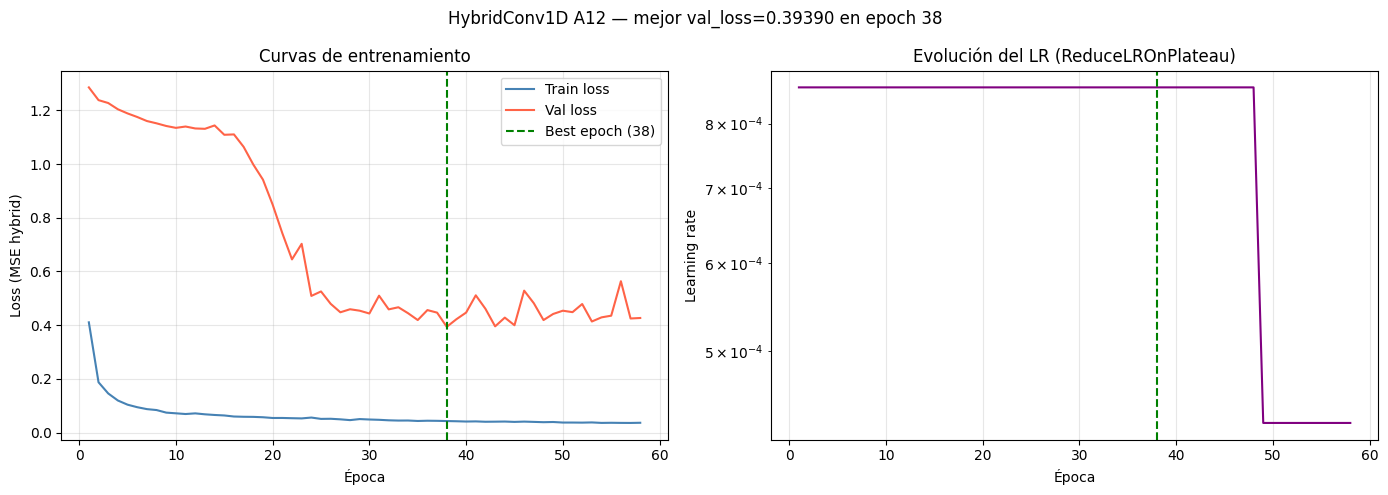

Train final (ep 38): 0.043035
Val   final (ep 38): 0.393899
Gap val/train: 9.2x  (⚠️ revisar overfitting)


In [21]:
# Restaurar el mejor modelo (checkpoint)
model.load_state_dict(best_model_wts)
model.eval()

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(train_hist) + 1)
axes[0].plot(epochs_ran, train_hist, label="Train loss",  color="steelblue",  lw=1.5)
axes[0].plot(epochs_ran, val_hist,   label="Val loss",    color="tomato",     lw=1.5)
axes[0].axvline(best_epoch, color="green", linestyle="--", lw=1.5, label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss (MSE hybrid)")
axes[0].set_title("Curvas de entrenamiento")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, lr_hist, color="purple", lw=1.5)
axes[1].axvline(best_epoch, color="green", linestyle="--", lw=1.5)
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Learning rate")
axes[1].set_title("Evolución del LR (ReduceLROnPlateau)")
axes[1].set_yscale("log"); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"HybridConv1D A12 — mejor val_loss={best_val_loss:.5f} en epoch {best_epoch}",
             fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "training_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"Train final (ep {best_epoch}): {train_hist[best_epoch-1]:.6f}")
print(f"Val   final (ep {best_epoch}): {val_hist[best_epoch-1]:.6f}")
gap = val_hist[best_epoch-1] / train_hist[best_epoch-1]
print(f"Gap val/train: {gap:.1f}x  ({'⚠️ revisar overfitting' if gap > 5 else '✅ aceptable'})")


## 7. Errores de reconstrucción y umbrales de detección

El **score de anomalía** de cada ventana es el MSE total de reconstrucción:
`error = alpha * MSE(cont) + (1-alpha) * MSE(disc)`.

Los umbrales `tau` se calculan sobre el **conjunto de test** (datos normales no vistos
durante el entrenamiento) y representan percentiles de la distribución de errores
de operación normal. En producción, una ventana se clasifica como anomalía si
`error > tau`.

> **Importante:** en la validación externa supervisada (notebook posterior)
> estos umbrales se re-calibran usando datos normales del mismo dataset A12.


In [22]:
def compute_reconstruction_errors(model, X_cont, X_disc, batch_size=256, alpha=0.5):
    """Error de reconstrucción por ventana. Devuelve arrays separados y combinado."""

    loader = DataLoader(
        TensorDataset(torch.tensor(X_cont, dtype=torch.float32),
                      torch.tensor(X_disc, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False
    )
    err_cont_list, err_disc_list = [], []
    model.eval()
    with torch.no_grad():
        for x_c, x_d in loader:
            x_c, x_d = x_c.to(device), x_d.to(device)
            x_c_hat, x_d_hat = model(x_c, x_d)
            err_cont_list.extend(torch.mean((x_c_hat - x_c)**2, dim=(1,2)).cpu().numpy())
            err_disc_list.extend(torch.mean((x_d_hat - x_d)**2, dim=1).cpu().numpy())
    err_cont = np.array(err_cont_list)
    err_disc = np.array(err_disc_list)
    err_comb = alpha * err_cont + (1-alpha) * err_disc
    return err_cont, err_disc, err_comb


# Calcular errores en train, val y test (todos datos normales)
err_tr_c, err_tr_d, err_tr = compute_reconstruction_errors(model, X_tr_c, X_tr_d, alpha=ALPHA)
err_va_c, err_va_d, err_va = compute_reconstruction_errors(model, X_va_c, X_va_d, alpha=ALPHA)
err_te_c, err_te_d, err_te = compute_reconstruction_errors(model, X_te_c, X_te_d, alpha=ALPHA)

print("Errores de reconstrucción en datos normales (score combinado):")
print(f"{'Conjunto':<8} {'Mean':>8} {'Std':>8} {'p50':>8} {'p90':>8} {'p95':>8} {'p99':>8}")
print("-" * 58)
for name, err in [("Train", err_tr), ("Val", err_va), ("Test", err_te)]:
    print(f"{name:<8} {err.mean():>8.5f} {err.std():>8.5f} "
          f"{np.percentile(err,50):>8.5f} {np.percentile(err,90):>8.5f} "
          f"{np.percentile(err,95):>8.5f} {np.percentile(err,99):>8.5f}")


Errores de reconstrucción en datos normales (score combinado):
Conjunto     Mean      Std      p50      p90      p95      p99
----------------------------------------------------------
Train     0.03571  0.18536  0.01365  0.03931  0.07655  0.29130
Val       0.39518  1.09903  0.06641  0.26909  4.44542  4.76574
Test     54326208.00000 580270464.00000  0.07671  0.23759  0.35903 744016512.00000


In [23]:
# Umbrales calculados sobre el TEST (datos normales no vistos)
# Test = último 20% temporal → más representativo del comportamiento estabilizado
PERCENTILES = [90, 95, 97.5, 99, 99.5]
tau_dict = {f"p{str(p).replace('.','_')}": float(np.percentile(err_te, p))
            for p in PERCENTILES}

print("Umbrales de detección (sobre test normal):")
for k, v in tau_dict.items():
    print(f"  {k:8s}: {v:.6f}")

# Verificación: FAR en test con cada umbral
print("\nFalse Alarm Rate en test normal:")
for k, tau in tau_dict.items():
    far = (err_te > tau).mean()
    print(f"  {k:8s}: FAR = {100*far:.2f}%  (esperado ≈ {100-float(k[1:].replace('_','.'))}%)")


Umbrales de detección (sobre test normal):
  p90     : 0.237587
  p95     : 0.359029
  p97_5   : 0.869825
  p99     : 744016512.000000
  p99_5   : 5060018688.000000

False Alarm Rate en test normal:
  p90     : FAR = 10.01%  (esperado ≈ 10.0%)
  p95     : FAR = 5.00%  (esperado ≈ 5.0%)
  p97_5   : FAR = 2.55%  (esperado ≈ 2.5%)
  p99     : FAR = 1.08%  (esperado ≈ 1.0%)
  p99_5   : FAR = 0.59%  (esperado ≈ 0.5%)


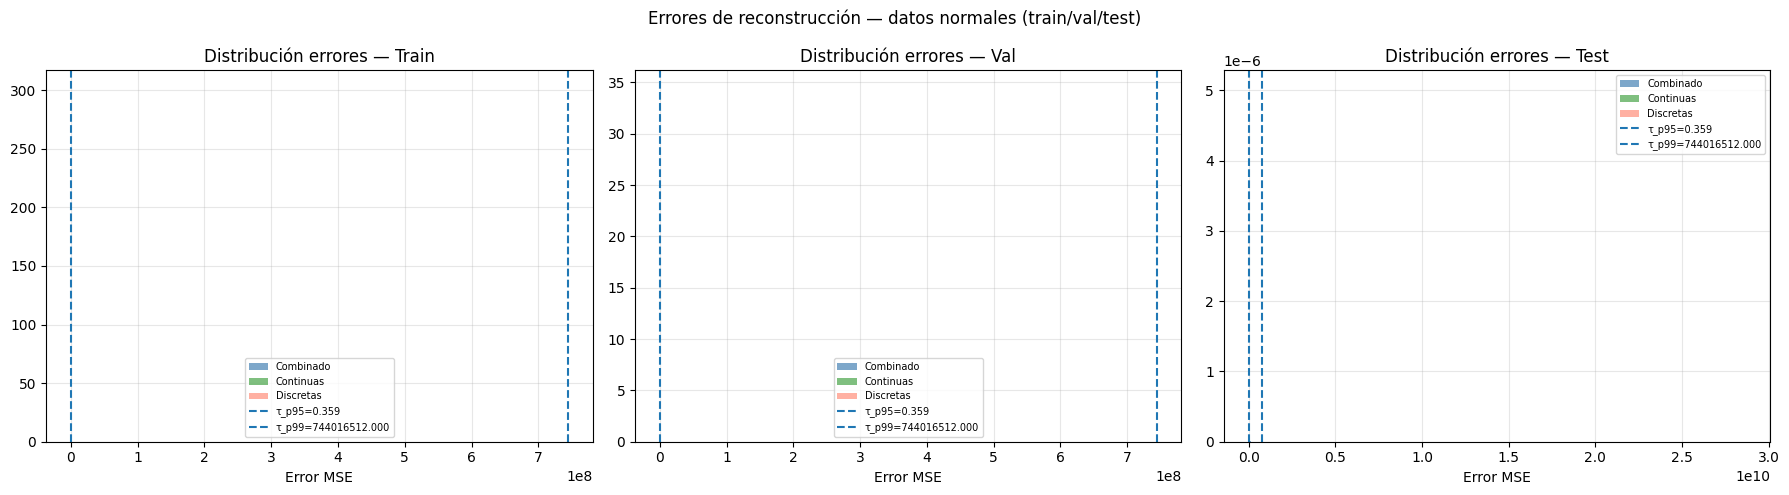

In [24]:
# Visualización distribuciones de errores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, err_c, err_d, err_comb) in zip(
    axes,
    [("Train", err_tr_c, err_tr_d, err_tr),
     ("Val",   err_va_c, err_va_d, err_va),
     ("Test",  err_te_c, err_te_d, err_te)]
):
    ax.hist(err_comb, bins=60, alpha=0.7, color="steelblue", density=True, label="Combinado")
    ax.hist(err_c,    bins=60, alpha=0.5, color="green",     density=True, label="Continuas")
    ax.hist(err_d,    bins=60, alpha=0.5, color="tomato",    density=True, label="Discretas")
    for k_tau, tau_val in tau_dict.items():
        if k_tau in ["p95", "p99"]:
            ax.axvline(tau_val, linestyle="--", lw=1.5, label=f"τ_{k_tau}={tau_val:.3f}")
    ax.set_title(f"Distribución errores — {name}")
    ax.set_xlabel("Error MSE"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("Errores de reconstrucción — datos normales (train/val/test)", fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "error_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()


## 8. Calidad de reconstrucción — visualización por sensor

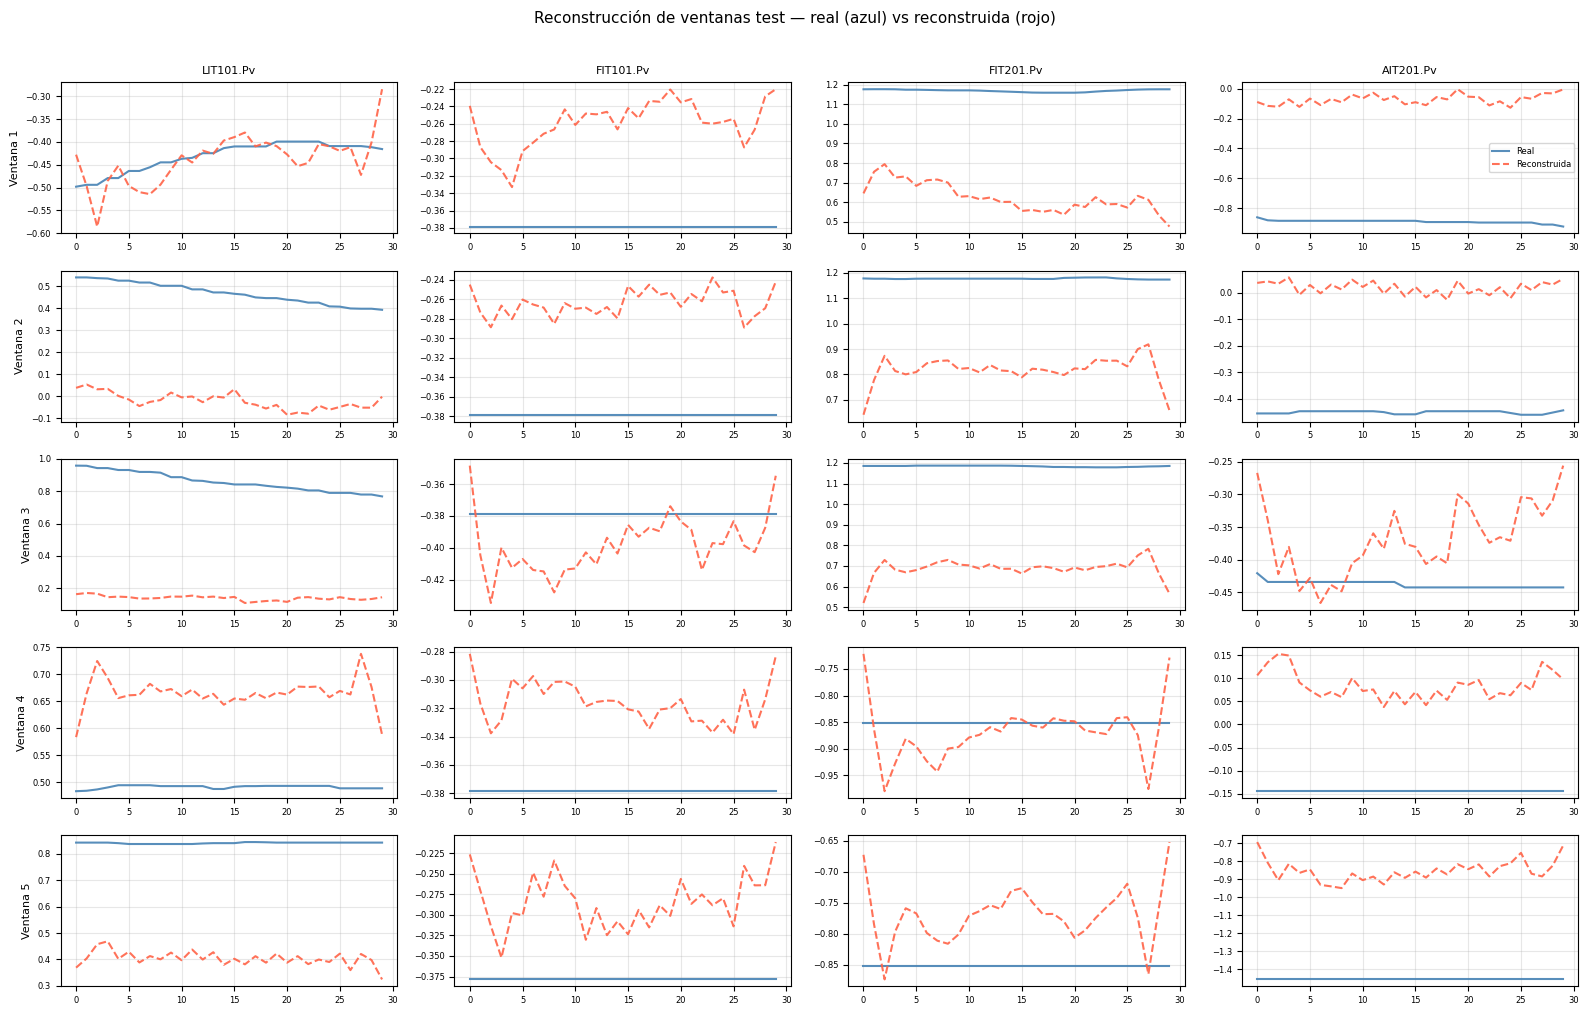

In [25]:
# Mostrar 5 ventanas reales vs reconstruidas para los 4 primeros sensores continuos
N_SHOW = 5
sample_idx = np.random.choice(len(X_te_c), N_SHOW, replace=False)

x_c_sample = torch.tensor(X_te_c[sample_idx], dtype=torch.float32).to(device)
x_d_sample = torch.tensor(X_te_d[sample_idx], dtype=torch.float32).to(device)

with torch.no_grad():
    x_c_hat_s, _ = model(x_c_sample, x_d_sample)

x_c_np     = x_c_sample.cpu().numpy()      # (N_SHOW, C, W)
x_c_hat_np = x_c_hat_s.cpu().numpy()

n_sensors = min(4, X_te_c.shape[1])
fig, axes = plt.subplots(N_SHOW, n_sensors, figsize=(4*n_sensors, 2*N_SHOW))

for i in range(N_SHOW):
    for j in range(n_sensors):
        ax = axes[i, j]
        ax.plot(x_c_np[i, j],     color="steelblue", lw=1.5, alpha=0.9, label="Real")
        ax.plot(x_c_hat_np[i, j], color="tomato",    lw=1.5, alpha=0.9, linestyle="--", label="Reconstruida")
        if i == 0: ax.set_title(continuous_cols[j], fontsize=8)
        if j == 0: ax.set_ylabel(f"Ventana {i+1}", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=6)
        if i == 0 and j == n_sensors-1: ax.legend(fontsize=6)

plt.suptitle("Reconstrucción de ventanas test — real (azul) vs reconstruida (rojo)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "reconstruction_quality.png"), dpi=120, bbox_inches="tight")
plt.show()


## 9. Guardar todos los artefactos

In [26]:
# 1. Modelo (mejor epoch)
torch.save(model.state_dict(), SAVE_DIR / "model_state.pt")

# 2. Umbrales
with open(SAVE_DIR / "tau_dict.json", "w") as f:
    json.dump(tau_dict, f, indent=4)

# 3. Columnas config — lo usan todos los notebooks posteriores
columns_config = {
    "continuous_cols": continuous_cols,
    "discrete_cols":   discrete_cols,
    "feature_cols":    feature_cols,
}
with open(SAVE_DIR / "columns_config.json", "w") as f:
    json.dump(columns_config, f, indent=4)

# 4. Config completa
config = {
    "version":           "a12_final_v1",
    "dataset":           "SWaT A12 Mar 2026",
    "csv_path":          str(RAW_CSV),
    "warmup_seconds":    120,
    "n_normal_rows":     int(df_work.shape[0]),
    "n_train":           len(df_train),
    "n_val":             len(df_val),
    "n_test":            len(df_test),
    "window_size":       WINDOW_SIZE,
    "stride":            STRIDE,
    "alpha":             float(ALPHA),
    "best_epoch":        best_epoch,
    "best_val_loss":     float(best_val_loss),
    "train_loss_at_best":float(train_hist[best_epoch-1]),
    "val_loss_at_best":  float(val_hist[best_epoch-1]),
    "n_windows_train":   int(len(X_tr_c)),
    "n_windows_val":     int(len(X_va_c)),
    "n_windows_test":    int(len(X_te_c)),
    "cont_channels":     int(X_tr_c.shape[1]),
    "disc_dim":          int(X_tr_d.shape[1]),
    "continuous_cols":   continuous_cols,
    "discrete_cols":     discrete_cols,
    "feature_cols":      feature_cols,
    "scenarios":         ["real_only", "synthetic_only", "real_plus_synthetic"],
    "model_params":      {k: (float(v) if isinstance(v, float) else v)
                         for k, v in bp.items()},
    "tau_dict":          tau_dict,
    "error_stats": {
        "test_mean":  float(err_te.mean()),
        "test_std":   float(err_te.std()),
        "test_p95":   float(np.percentile(err_te, 95)),
        "test_p99":   float(np.percentile(err_te, 99)),
    }
}
with open(SAVE_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ Artefactos guardados:")
for fp in sorted(SAVE_DIR.iterdir()):
    sz = fp.stat().st_size
    unit = "KB" if sz < 1e6 else "MB"
    print(f"   {fp.name:<40} {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {unit}")


✅ Artefactos guardados:
   best_model_training_curve.png              41.5 KB
   columns_config.json                         2.9 KB
   config.json                                 4.7 KB
   disc_max_dict.pkl                           0.7 KB
   error_distributions.png                    61.8 KB
   model_state.pt                            662.3 KB
   model_state_optuna_best.pt                662.8 KB
   optuna_best_config.json                     4.9 KB
   optuna_convergence.png                     62.7 KB
   optuna_trials.csv                           3.3 KB
   reconstruction_quality.png                257.9 KB
   scaler_cont.pkl                             1.3 KB
   tau_dict.json                               0.2 KB
   training_curve.png                         72.0 KB


## 10. Resumen y próximos pasos

### Métricas del modelo final

El autoencoder híbrido fue entrenado **exclusivamente con datos de operación normal**
de SWaT A12. La calidad de reconstrucción en datos normales determina la calibración
del umbral de detección: errores más bajos y distribución más compacta → umbrales
más sensibles a desviaciones.

### Archivos generados

| Archivo | Uso en notebooks posteriores |
|---------|------------------------------|
| `model_state.pt` | TimeGAN (TSTR), validación externa |
| `scaler_cont.pkl` | TimeGAN, validación externa |
| `disc_max_dict.pkl` | TimeGAN, validación externa |
| `tau_dict.json` | Validación interna y externa TSTR |
| `columns_config.json` | Todos |
| `config.json` | Todos |

### Próximo paso: TimeGAN (notebook 02)

El TimeGAN generará datos sintéticos de operación normal a partir de las
mismas ventanas de train. Los datos sintéticos se usarán en el experimento
TSTR (Train on Synthetic, Test on Real) para evaluar si la augmentación
mejora la detección de ataques.
